In [1]:
import torch

FP4_GRID = torch.tensor([
    -6.0,
    -4.0,
    -3.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    -0.0,
    +0.0,
    +0.5,
    +1.0,
    +1.5,
    +2.0,
    +3.0,
    +4.0,
    +6.0,
])

def round_scales(scales):            
    s_dec = scales.abs().max() / (447.99 * 6.0)
    s_dec[s_dec == 0] = 1.0
    s_dec_b = scales / 6.0
    s_dec_b_e4m3 = (s_dec_b / s_dec).to(torch.float8_e4m3fn).float()
    s_dec_b_e4m3[s_dec_b_e4m3 == 0] = 1.0
    s_enc_b_inv = s_dec_b_e4m3 * s_dec
    return s_enc_b_inv


def get_gaussian() -> torch.Tensor:
    return torch.randn((2**20, 16))
    
    
def normalize(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    scales = x.abs().max(dim=-1, keepdim=True)[0]
    rounded_scales = round_scales(scales)

    return x / rounded_scales, rounded_scales

def index_rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = torch.bucketize(x, grid)

    lo = torch.clamp(inds - 1, min=0, max=grid.shape[-1] - 1)
    hi = torch.clamp(inds,     min=0, max=grid.shape[-1] - 1)

    low = grid[lo]
    high = grid[hi]

    return torch.where(
        (high - x) <= (x - low),
        hi,
        lo,
    )


def rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x, grid)
    return grid[rtn_inds]

In [2]:
x = get_gaussian()
x_norm, scales = normalize(x)

In [3]:
def quantize_nvfp4(x_norm: torch.Tensor, scales: torch.Tensor) -> torch.Tensor:
    return rtn_grid(x_norm, FP4_GRID) * scales

x_fp4 = quantize_nvfp4(x_norm, scales)
err_fp4 = (x - x_fp4).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 err: {err_fp4:.4f}")

NVFP4 err: 0.0090


In [4]:
def get_best_fp4_downcast(x_norm: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x_norm, FP4_GRID)
    
    downcast = rtn_inds >> 1 
    x_flat = x_norm.flatten()
    downcast_flat = downcast.flatten()
    group_sums = torch.bincount(downcast_flat, weights=x_flat)
    group_counts = torch.bincount(downcast_flat)
    centers_of_mass = group_sums / group_counts.clamp(min=1)
    
    return centers_of_mass

In [5]:
BEST_FP4_DOWNCAST = get_best_fp4_downcast(x_norm)
BEST_FP4_DOWNCAST

tensor([-4.8908, -2.5499, -1.2362, -0.3727,  0.3726,  1.2361,  2.5500,  4.8909])

In [6]:
def quantize_best_fp4_downcast(x_norm: torch.Tensor, scales: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x_norm, FP4_GRID)
    downcast = rtn_inds >> 1
    
    decoded = BEST_FP4_DOWNCAST[downcast]
    
    return decoded * scales

x_fp4_downcast = quantize_best_fp4_downcast(x_norm, scales)
err_fp4_downcast = (x - x_fp4_downcast).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 err: {err_fp4:.4f}")
print(f"NVFP4->LUT3 Downcast err: {err_fp4_downcast:.4f}")

NVFP4 err: 0.0090
NVFP4->LUT3 Downcast err: 0.0363


In [7]:
print(f"NVFP4 err: {err_fp4:.4f}")
print(f"NVFP4->LUT3 Downcast err: {err_fp4_downcast:.4f}")

NVFP4 err: 0.0090
NVFP4->LUT3 Downcast err: 0.0363


In [8]:
def lloyd_grid(x: torch.Tensor, n_levels: int = 8, n_iters: int = 200) -> torch.Tensor:
    """MSE-optimal scalar quantization grid via Lloyd's algorithm (1-D k-means)."""
    x_flat = x.flatten()
    qs = torch.linspace(0, 1, n_levels + 2)[1:-1]
    # init centroids from quantiles of a subsample (torch.quantile has a 2**24 size limit)
    sample = x_flat[torch.randperm(x_flat.numel())[:1_000_000]]
    centers = torch.quantile(sample, qs)
    for _ in range(n_iters):
        inds = index_rtn_grid(x_flat, centers)
        sums = torch.bincount(inds, weights=x_flat, minlength=n_levels).double()
        counts = torch.bincount(inds, minlength=n_levels).double()
        # keep empty clusters at their previous center: setting them to 0 would break the
        # sorted-grid invariant that index_rtn_grid (bucketize) relies on and collapse the grid.
        new_centers = centers.double().clone()
        nonempty = counts > 0
        new_centers[nonempty] = sums[nonempty] / counts[nonempty]
        new_centers = new_centers.to(centers.dtype)
        if torch.allclose(new_centers, centers, atol=1e-7):
            centers = new_centers
            break
        centers = new_centers
    return centers


def quantize_lloyd(x_norm: torch.Tensor, scales: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = index_rtn_grid(x_norm, grid)
    return grid[inds] * scales


BEST_LLOYD_GRID = lloyd_grid(x_norm)
x_lloyd = quantize_lloyd(x_norm, scales, BEST_LLOYD_GRID)
err_lloyd = (x - x_lloyd).pow(2).mean() / x.pow(2).mean()
print(f"Lloyd 3-bit grid: {BEST_LLOYD_GRID}")
print(f"NVFP4->LUT3 Lloyd err: {err_lloyd:.4f}")

Lloyd 3-bit grid: tensor([-5.5576, -3.5817, -2.0239, -0.6550,  0.6587,  2.0282,  3.5859,  5.5614])
NVFP4->LUT3 Lloyd err: 0.0240


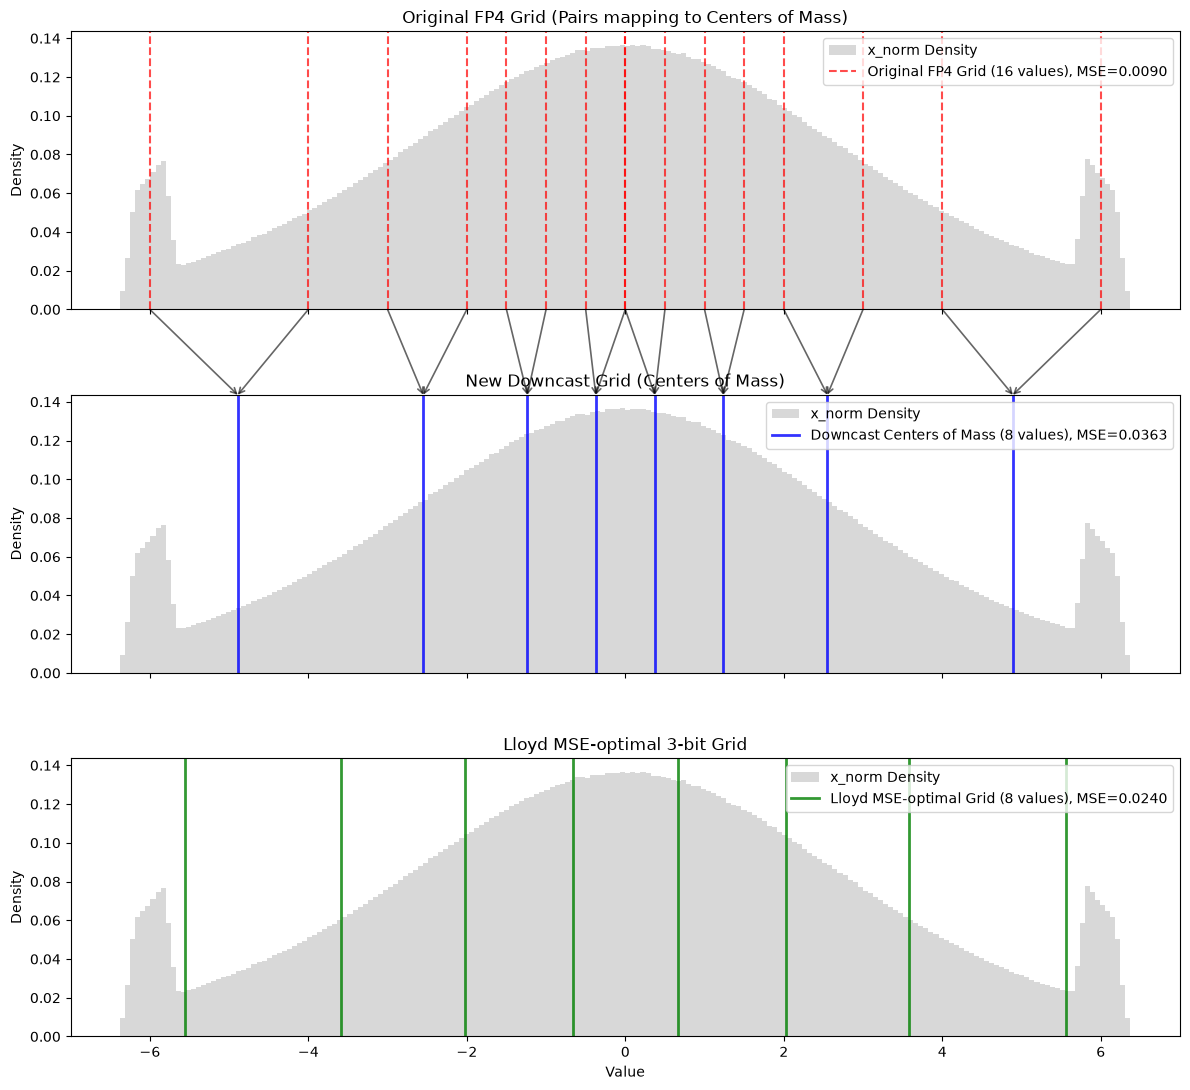

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch


# 3. Plotting Setup
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
x_np = x_norm.flatten().numpy()

# Plot x_norm density on all subplots
for ax in (ax1, ax2, ax3):
    ax.hist(x_np, bins=200, density=True, alpha=0.3, color='gray', label='x_norm Density')

max_y2 = ax2.get_ylim()[1]

# 4. Plot Original Grid (Top)
for i, val in enumerate(FP4_GRID):
    label = f'Original FP4 Grid (16 values), MSE={err_fp4:.4f}' if i == 0 else ""
    ax1.axvline(val.item(), color='red', linestyle='--', alpha=0.7, label=label)

# 5. Plot Downcast Centers of Mass (Middle)
for i, val in enumerate(BEST_FP4_DOWNCAST):
    label = f'Downcast Centers of Mass (8 values), MSE={err_fp4_downcast:.4f}' if i == 0 else ""
    ax2.axvline(val.item(), color='blue', linestyle='-', linewidth=2, alpha=0.8, label=label)

# 6. Plot Lloyd MSE-optimal grid (Bottom)
for i, val in enumerate(BEST_LLOYD_GRID):
    label = f'Lloyd MSE-optimal Grid (8 values), MSE={err_lloyd:.4f}' if i == 0 else ""
    ax3.axvline(val.item(), color='green', linestyle='-', linewidth=2, alpha=0.8, label=label)

# 7. Draw Connection Arrows (FP4 pairs -> Centers of Mass)
for i, val in enumerate(FP4_GRID):
    com_idx = i >> 1
    com_val = BEST_FP4_DOWNCAST[com_idx].item()

    # ConnectionPatch maps coordinates across different subplots
    con = ConnectionPatch(
        xyA=(val.item(), 0),          # Start at y=0 on ax1 (bottom of top subplot)
        xyB=(com_val, max_y2),        # End at max_y on ax2 (top of middle subplot)
        coordsA="data", coordsB="data",
        axesA=ax1, axesB=ax2,
        color="black", arrowstyle="->", shrinkB=0, lw=1.2, alpha=0.6
    )
    ax1.add_artist(con)

# Formatting
ax1.set_title("Original FP4 Grid (Pairs mapping to Centers of Mass)")
ax2.set_title("New Downcast Grid (Centers of Mass)")
ax3.set_title("Lloyd MSE-optimal 3-bit Grid")
for ax in (ax1, ax2, ax3):
    ax.set_ylabel("Density")
    ax.legend(loc='upper right')
ax3.set_xlabel("Value")
ax1.set_xlim(-7, 7)

plt.tight_layout()
plt.savefig('fp4_downcast_visualization.png', dpi=150)

## Standalone implementation

In [10]:
import torch


FP4_GRID = torch.tensor([
    -6.0,
    -4.0,
    -3.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    -0.0,
    +0.0,
    +0.5,
    +1.0,
    +1.5,
    +2.0,
    +3.0,
    +4.0,
    +6.0,
])


BEST_FP4_DOWNCAST_GRID = torch.tensor([
    -4.890,
    -2.550,
    -1.236,
    -0.372,
    +0.372,
    +1.236,
    +2.550,
    +4.890,
])


def round_scales(scales):            
    s_dec = scales.abs().max() / (447.99 * 6.0)
    s_dec[s_dec == 0] = 1.0
    s_dec_b = scales / 6.0
    s_dec_b_e4m3 = (s_dec_b / s_dec).to(torch.float8_e4m3fn).float()
    s_dec_b_e4m3[s_dec_b_e4m3 == 0] = 1.0
    s_enc_b_inv = s_dec_b_e4m3 * s_dec
    return s_enc_b_inv


def index_rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = torch.bucketize(x, grid)

    lo = torch.clamp(inds - 1, min=0, max=grid.shape[-1] - 1)
    hi = torch.clamp(inds,     min=0, max=grid.shape[-1] - 1)

    low = grid[lo]
    high = grid[hi]

    return torch.where(
        (high - x) <= (x - low),
        hi,
        lo,
    )

def downcast_double_round(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    assert x.device == FP4_GRID.device
    assert x.device == BEST_FP4_DOWNCAST_GRID.device
    assert x.numel() % 16 == 0
    
    orig_shape = x.shape
    x_g = x.reshape(-1, 16)
    scales = x_g.abs().max(dim=-1, keepdim=True)[0]
    rounded_scales = round_scales(scales)
    
    x_scaled = x_g / rounded_scales
    
    fp4_idx = index_rtn_grid(x_scaled, FP4_GRID)
    downcast_idx = fp4_idx >> 1
    
    x_fp4 = FP4_GRID[fp4_idx] * rounded_scales
    x_dc3 = BEST_FP4_DOWNCAST_GRID[downcast_idx] * rounded_scales
    
    return x_fp4.reshape(orig_shape), x_dc3.reshape(orig_shape)
    

In [11]:
tensor = torch.randn(2**24)
tensor_fp4, tensor_dc3 = downcast_double_round(tensor)

fp4_err = (tensor - tensor_fp4).pow(2).mean() / x.pow(2).mean()
dc3_err = (tensor - tensor_dc3).pow(2).mean() / x.pow(2).mean()

print(f"FP4 err: {fp4_err:.4f}")
print(f"DC3 err: {dc3_err:.4f}")

FP4 err: 0.0091
DC3 err: 0.0363


## Signed

In [12]:
def normalize_signed(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    scales, scales_idx = x.abs().max(dim=-1, keepdim=True)
    signes = x.take_along_dim(scales_idx, -1).sign()
    print(scales.shape, signes.shape)
    scales = scales * signes
    
    rounded_scales = round_scales(scales)

    return x / rounded_scales, rounded_scales

x_norm_signed, scales_signed = normalize_signed(x)

torch.Size([1048576, 1]) torch.Size([1048576, 1])


In [13]:
x_fp4_signed = quantize_nvfp4(x_norm_signed, scales_signed)
err_fp4_signed = (x - x_fp4_signed).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 Signed err: {err_fp4_signed:.4f}")

NVFP4 Signed err: 0.0090


In [14]:
BEST_FP4_SIGNED_DOWNCAST = get_best_fp4_downcast(x_norm_signed)
BEST_FP4_SIGNED_DOWNCAST

tensor([-4.5062, -2.5496, -1.2364, -0.3728,  0.3725,  1.2359,  2.5503,  5.1217])

In [15]:
def quantize_best_fp4_signed_downcast(x_norm_signed: torch.Tensor, scales_signed: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x_norm_signed, FP4_GRID)
    downcast = rtn_inds >> 1
    
    decoded = BEST_FP4_SIGNED_DOWNCAST[downcast]
    
    return decoded * scales_signed

x_fp4_signed_downcast = quantize_best_fp4_signed_downcast(x_norm_signed, scales_signed)
err_fp4_signed_downcast = (x - x_fp4_signed_downcast).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 Signed err: {err_fp4_signed:.4f}")
print(f"NVFP4->LUT3 Signed Downcast err: {err_fp4_signed_downcast:.4f}")

NVFP4 Signed err: 0.0090
NVFP4->LUT3 Signed Downcast err: 0.0334


In [16]:
BEST_LLOYD_SIGNED_GRID = lloyd_grid(x_norm_signed)
x_lloyd_signed = quantize_lloyd(x_norm_signed, scales_signed, BEST_LLOYD_SIGNED_GRID)
err_lloyd_signed = (x - x_lloyd_signed).pow(2).mean() / x.pow(2).mean()
print(f"Lloyd 3-bit signed grid: {BEST_LLOYD_SIGNED_GRID}")
print(f"NVFP4->LUT3 Signed Lloyd err: {err_lloyd_signed:.4f}")

Lloyd 3-bit signed grid: tensor([-4.7940, -3.0606, -1.6280, -0.3370,  0.9285,  2.2669,  3.7973,  5.7882])
NVFP4->LUT3 Signed Lloyd err: 0.0218


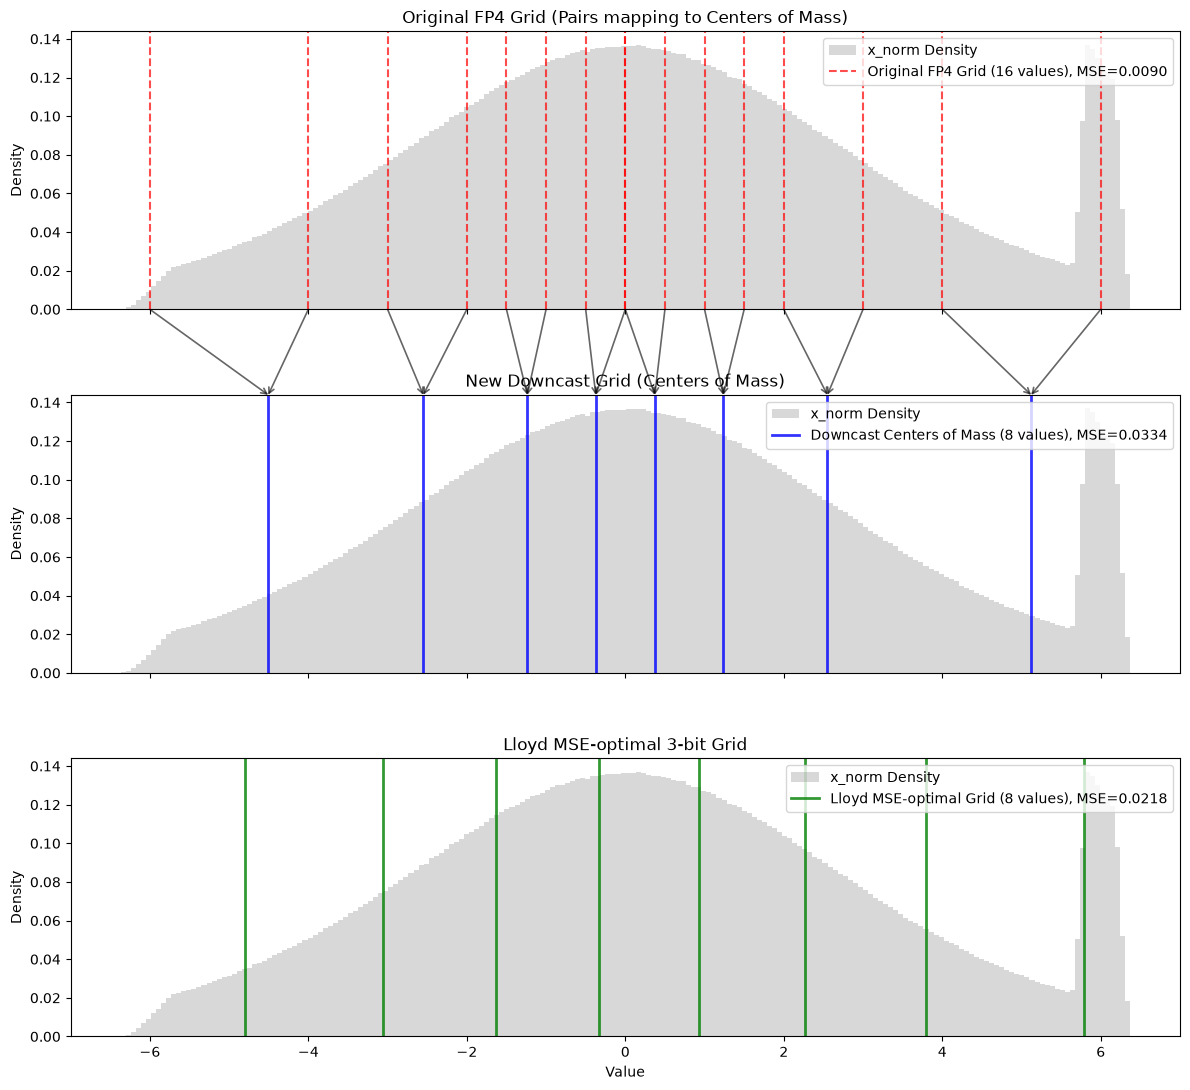

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch


# 3. Plotting Setup
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
x_np = x_norm_signed.flatten().numpy()

# Plot x_norm density on all subplots
for ax in (ax1, ax2, ax3):
    ax.hist(x_np, bins=200, density=True, alpha=0.3, color='gray', label='x_norm Density')

max_y2 = ax2.get_ylim()[1]

# 4. Plot Original Grid (Top)
for i, val in enumerate(FP4_GRID):
    label = f'Original FP4 Grid (16 values), MSE={err_fp4_signed:.4f}' if i == 0 else ""
    ax1.axvline(val.item(), color='red', linestyle='--', alpha=0.7, label=label)

# 5. Plot Downcast Centers of Mass (Middle)
for i, val in enumerate(BEST_FP4_SIGNED_DOWNCAST):
    label = f'Downcast Centers of Mass (8 values), MSE={err_fp4_signed_downcast:.4f}' if i == 0 else ""
    ax2.axvline(val.item(), color='blue', linestyle='-', linewidth=2, alpha=0.8, label=label)

# 6. Plot Lloyd MSE-optimal grid (Bottom)
for i, val in enumerate(BEST_LLOYD_SIGNED_GRID):
    label = f'Lloyd MSE-optimal Grid (8 values), MSE={err_lloyd_signed:.4f}' if i == 0 else ""
    ax3.axvline(val.item(), color='green', linestyle='-', linewidth=2, alpha=0.8, label=label)

# 7. Draw Connection Arrows (FP4 pairs -> Centers of Mass)
for i, val in enumerate(FP4_GRID):
    com_idx = i >> 1
    com_val = BEST_FP4_SIGNED_DOWNCAST[com_idx].item()

    # ConnectionPatch maps coordinates across different subplots
    con = ConnectionPatch(
        xyA=(val.item(), 0),          # Start at y=0 on ax1 (bottom of top subplot)
        xyB=(com_val, max_y2),        # End at max_y on ax2 (top of middle subplot)
        coordsA="data", coordsB="data",
        axesA=ax1, axesB=ax2,
        color="black", arrowstyle="->", shrinkB=0, lw=1.2, alpha=0.6
    )
    ax1.add_artist(con)

# Formatting
ax1.set_title("Original FP4 Grid (Pairs mapping to Centers of Mass)")
ax2.set_title("New Downcast Grid (Centers of Mass)")
ax3.set_title("Lloyd MSE-optimal 3-bit Grid")
for ax in (ax1, ax2, ax3):
    ax.set_ylabel("Density")
    ax.legend(loc='upper right')
ax3.set_xlabel("Value")
ax1.set_xlim(-7, 7)

plt.tight_layout()
plt.savefig('fp4_signed_downcast_visualization.png', dpi=150)

## Signed standalone implementation

In [18]:
import torch


FP4_GRID = torch.tensor([
    -6.0,
    -4.0,
    -3.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    -0.0,
    +0.0,
    +0.5,
    +1.0,
    +1.5,
    +2.0,
    +3.0,
    +4.0,
    +6.0,
])


# MSE-optimal 3-bit grids for the signed scheme (scale absorbs the sign of the max-abs element).
BEST_FP4_SIGNED_DOWNCAST_GRID = torch.tensor([
    -4.506,
    -2.550,
    -1.236,
    -0.372,
    +0.373,
    +1.236,
    +2.550,
    +5.120,
])

BEST_LLOYD_SIGNED_GRID = torch.tensor([
    -4.795,
    -3.062,
    -1.631,
    -0.339,
    +0.927,
    +2.265,
    +3.797,
    +5.788,
])


def round_scales(scales):
    s_dec = scales.abs().max() / (447.99 * 6.0)
    s_dec[s_dec == 0] = 1.0
    s_dec_b = scales / 6.0
    s_dec_b_e4m3 = (s_dec_b / s_dec).to(torch.float8_e4m3fn).float()
    s_dec_b_e4m3[s_dec_b_e4m3 == 0] = 1.0
    s_enc_b_inv = s_dec_b_e4m3 * s_dec
    return s_enc_b_inv


def index_rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = torch.bucketize(x, grid)

    lo = torch.clamp(inds - 1, min=0, max=grid.shape[-1] - 1)
    hi = torch.clamp(inds,     min=0, max=grid.shape[-1] - 1)

    low = grid[lo]
    high = grid[hi]

    return torch.where(
        (high - x) <= (x - low),
        hi,
        lo,
    )


def _signed_normalize(x_g: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    """Group-wise normalization where the scale absorbs the sign of the max-abs element."""
    scales, scales_idx = x_g.abs().max(dim=-1, keepdim=True)
    signs = x_g.take_along_dim(scales_idx, -1).sign()
    rounded_scales = round_scales(scales * signs)
    return x_g / rounded_scales, rounded_scales


def downcast_double_round_signed(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    """Signed double-quant: 4-bit FP4 and the 3-bit downcast (FP4-pair centers of mass) from one tensor."""
    assert x.device == FP4_GRID.device == BEST_FP4_SIGNED_DOWNCAST_GRID.device
    assert x.numel() % 16 == 0

    orig_shape = x.shape
    x_g = x.reshape(-1, 16)
    x_scaled, rounded_scales = _signed_normalize(x_g)

    fp4_idx = index_rtn_grid(x_scaled, FP4_GRID)
    downcast_idx = fp4_idx >> 1

    x_fp4 = FP4_GRID[fp4_idx] * rounded_scales
    x_dc3 = BEST_FP4_SIGNED_DOWNCAST_GRID[downcast_idx] * rounded_scales

    return x_fp4.reshape(orig_shape), x_dc3.reshape(orig_shape)


def independent_double_round_signed(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    """Signed double-quant: 4-bit FP4 and an independent nearest round to the 3-bit Lloyd grid."""
    assert x.device == FP4_GRID.device == BEST_LLOYD_SIGNED_GRID.device
    assert x.numel() % 16 == 0

    orig_shape = x.shape
    x_g = x.reshape(-1, 16)
    x_scaled, rounded_scales = _signed_normalize(x_g)

    fp4_idx = index_rtn_grid(x_scaled, FP4_GRID)
    lloyd_idx = index_rtn_grid(x_scaled, BEST_LLOYD_SIGNED_GRID)

    x_fp4 = FP4_GRID[fp4_idx] * rounded_scales
    x_lloyd3 = BEST_LLOYD_SIGNED_GRID[lloyd_idx] * rounded_scales

    return x_fp4.reshape(orig_shape), x_lloyd3.reshape(orig_shape)

In [19]:
tensor = torch.randn(2**24)

tensor_fp4, tensor_dc3 = downcast_double_round_signed(tensor)
_, tensor_lloyd3 = independent_double_round_signed(tensor)

ref = tensor.pow(2).mean()
fp4_err = (tensor - tensor_fp4).pow(2).mean() / ref
dc3_err = (tensor - tensor_dc3).pow(2).mean() / ref
lloyd3_err = (tensor - tensor_lloyd3).pow(2).mean() / ref

print(f"FP4 err:            {fp4_err:.4f}")
print(f"Downcast 3-bit err: {dc3_err:.4f}")
print(f"Lloyd 3-bit err:    {lloyd3_err:.4f}")

FP4 err:            0.0090
Downcast 3-bit err: 0.0334
Lloyd 3-bit err:    0.0218


In [21]:
x_norm_signed_2d = x_norm_signed.reshape(-1, 2)

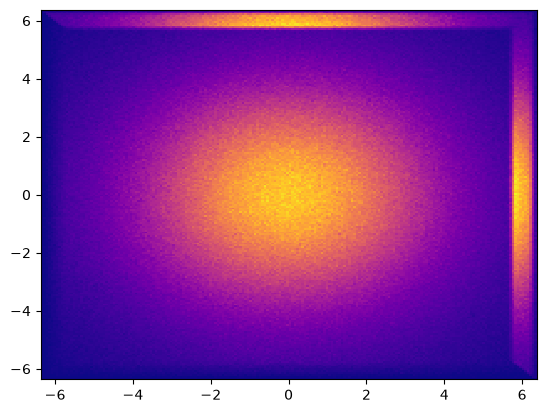

In [24]:
plt.hist2d(x_norm_signed_2d[:, 0], x_norm_signed_2d[:, 1], bins=200, density=True, cmap='plasma')
plt.show()